In [11]:
from matplotlib.pyplot import *
from pandas import read_csv
from numpy import *

average fringe width is  0.319 mm


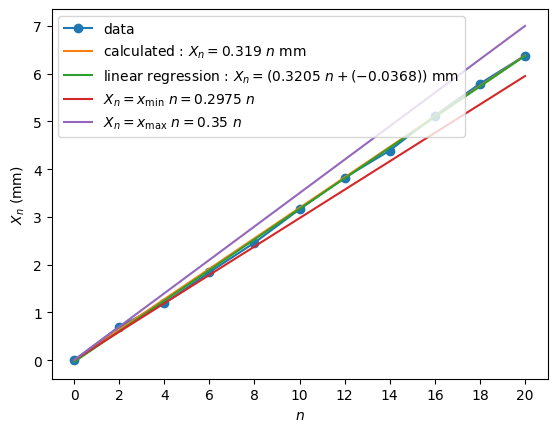

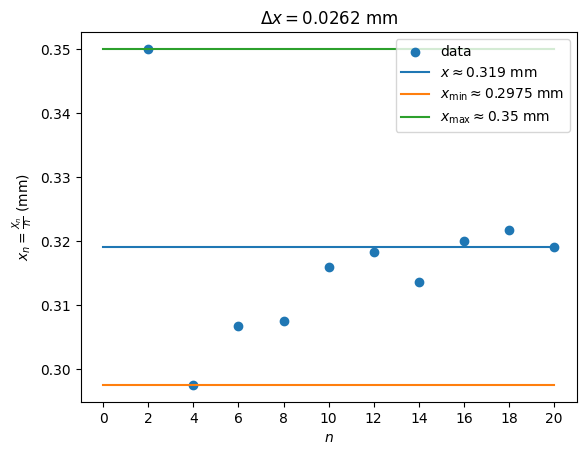

In [12]:
df = read_csv("Read.csv")
nlis = df['n'].values
X = df["X_n"].values
X = X[0] - X
plot(nlis,X,'-o')
xticks(nlis)
x = (X[-1] - X[0])/20
print("average fringe width is ",round(x,6),"mm")
t = linspace(0,20,1000)
plot(t,x*t)
data = array([[n,1] for n in nlis])
theta = dot(linalg.inv(data.T @ data) @ data.T , X)
x_r,c = theta
plot(t,x_r*t+c)

xlis = [(X[i]-X[0])/(nlis[i]-nlis[0]) for i in range(1,len(nlis))]

xmax = max(xlis)
xmin = min(xlis)

plot(t,xmin*t)
plot(t,xmax*t)

legend(["data",
        f"calculated : $X_n = {round(x,4)}\ n$ mm",
        f"linear regression : $X_n = ({round(x_r,4)}\ n+({round(c,4)}))$ mm",
        r"$ X_n = x_\text{min} \ n " + f" = {round(xmin,4)} \ n $",
        r"$ X_n = x_\text{max} \ n " + f" = {round(xmax,4)} \ n $"
        ])
xlabel("$n$")
ylabel(r"$X_n \text{ (mm) }$")

figure()
scatter(nlis[1:],xlis)
xticks(nlis)
xlabel("$n$")
ylabel(r"$x_n = \frac{X_n}{n} \text{ (mm)}$")
plot([min(nlis),max(nlis)],[x,x])
plot([min(nlis),max(nlis)],[xmin,xmin])
plot([min(nlis),max(nlis)],[xmax,xmax])
legend([
    "data",
    r"$x \approx " + f"{round(x,4)} $ mm",
    r"$x_\text{min} \approx " + f"{round(xmin,4)} $ mm",
    r"$x_\text{max} \approx " + f"{round(xmax,4)} $ mm",
],loc="upper right")
dx = (xmax - xmin)/2
title(r"$\Delta x = "+ f"{round(dx,4)} $ mm")
df.to_excel("Data.xlsx")

In [13]:
D = 1230-115
P111 = 13.1
P112 = 6.9
d11 = P111 - P112 #an approximation, because original values were not accurate
P211 = 10.32
P212 = 9.61
#d21 = 10.32-9.61
d21 = P211 - P212
c = (P211 + P212 + P111 + P112)/4
P121 = (P111 - c)/2 + c - 0.1
P122 = (P112 -c)/2 +c + 0.1
#d12 = (12.9 - 7.1)/2 # at a different D
d12 = P121 -P122
P221 = 2*(P211 - c) + c
P222 = 2*(P212 -c) +c
#d22 = 2*(10.32-9.61) # at a different D
d22 = P221 - P222
print([P121,P122,d12])
print([P221,P222,d22])
d_1 = (d11*d21)**(1/2)
d_2 = (d12*d22)**(1/2)
d = (d_1 + d_2)/2
dd = abs(d_2 - d_1)/2
L = [
    [r"xmin               ",xmin],
    [r"xmax               ",xmax],
    [r"dmin               ",min(d_1,d_2)],
    [r"dmax               ",max(d_1,d_2)],
    [r"d                  ",d],
    [r"error in d         ",dd],
    [r"D                  ",D],
    [r"x                  ",x],
    [r"error in x         ",dx],
    [r"% error in x       ",100*dx/x],
    [r"% error in d       ",100*dd/d],
    [r"std. dev. in x     ",var(xlis)**0.5],
    [r"std. dev. in d     ",var([d_1,d_2])**0.5],
    [r"std. dev. in lambda",((1e6*d*(var(xlis)**0.5) + 1e6*x*(var([d_1,d_2])**0.5))/D)],
    [r"error in lambda    ",(1e6*dx*d+1e6*dd*x)/D],
]
for row in L:
    print(row[0],"\t=\t",round(row[1],4))

[11.44125, 8.54125, 2.9000000000000004]
[10.6575, 9.237499999999999, 1.4200000000000017]
xmin                	=	 0.2975
xmax                	=	 0.35
dmin                	=	 2.0293
dmax                	=	 2.0981
d                   	=	 2.0637
error in d          	=	 0.0344
D                   	=	 1115
x                   	=	 0.319
error in x          	=	 0.0262
% error in x        	=	 8.2288
% error in d        	=	 1.6671
std. dev. in x      	=	 0.0131
std. dev. in d      	=	 0.0344
std. dev. in lambda 	=	 34.0854
error in lambda     	=	 58.4277


In [14]:
lambda_val = (d*x)/D
print(lambda_val * 1e6,'nm')

590.4189273065143 nm


In [15]:
LC = 0.01 #mm
ddlc1 = (LC/2) * (d21 +d11)/(2*(d11*d21)**0.5)
ddlc2 = (LC/2) * (d22 +d12)/(2*(d12*d22)**0.5)
ddlc = (ddlc1 + ddlc2)/2
dxlc = LC/len(nlis)
dlamblc = (1e6*x*ddlc + 1e6*d*dxlc)/D
print("d :",ddlc,'mm')
print("x :",dxlc,'mm')
print("lambda :",dlamblc,"nm")
print("lambda fe:",100*1e-6*dlamblc/lambda_val,"%")

d : 0.006777866031920474 mm
x : 0.0009090909090909091 mm
lambda : 3.6217229283532255 nm
lambda fe: 0.6134157901873999 %
